# Q1(a) — Total Least Squares Line Fitting

## Objective
Fit a line to the first point scatter in `lines.csv` using **Total Least Squares (TLS)**.

Unlike Ordinary Least Squares (OLS) which minimises vertical errors only,
TLS minimises the **perpendicular distance** from each point to the line.
This is more appropriate when both x and y have measurement noise.

## Method
We use **Singular Value Decomposition (SVD)** on the mean-centred data matrix.
The right singular vector corresponding to the **smallest singular value**
gives the normal to the best-fit line.

The line equation is:  **ax + by = d**
where [a, b] is the unit normal vector and d = a*x̄ + b*ȳ

In [7]:
import numpy as np
import matplotlib.pyplot as plt

## Step 1 — Load the dataset
Load `lines.csv` and extract only the **first line's points** (columns x1 and y1).

In [8]:
# Load the CSV file
D = np.genfromtxt('../images/lines.csv', delimiter=',', skip_header=1)

# Extract x and y columns for the first line only
x1 = D[:, 0]   # column x1
y1 = D[:, 3]   # column y1

print(f"Number of points in line 1: {len(x1)}")
print(f"First 5 x values: {x1[:5]}")
print(f"First 5 y values: {y1[:5]}")

Number of points in line 1: 100
First 5 x values: [-5.30547099 -5.5403588  -4.98212753 -4.49570614 -4.44215386]
First 5 y values: [-12.66633342 -11.00772693 -11.69731474 -11.97801037 -12.41495176]


## Step 2 — Mean-centre the data
TLS requires the data to be centred around the mean before applying SVD.
We subtract the mean from both x and y coordinates.

In [9]:
# Compute the mean of x and y
x_mean = np.mean(x1)
y_mean = np.mean(y1)

print(f"Mean of x1: {x_mean:.4f}")
print(f"Mean of y1: {y_mean:.4f}")

# Mean-centre the data
x_centered = x1 - x_mean
y_centered = y1 - y_mean

# Stack into a data matrix of shape (N, 2)
A = np.column_stack((x_centered, y_centered))
print(f"\nData matrix A shape: {A.shape}")

Mean of x1: -0.0195
Mean of y1: -6.0110

Data matrix A shape: (100, 2)


## Step 3 — Apply SVD
We decompose the data matrix A using SVD:  A = U Σ Vᵀ

The rows of Vᵀ (columns of V) are the principal directions.
The **last row of Vᵀ** (smallest singular value) gives the 
**normal vector [a, b]** to the best-fit line.

In [10]:
# Apply SVD to the mean-centred data matrix
U, S, Vt = np.linalg.svd(A)

print(f"Singular values: {S}")
print(f"Vt (right singular vectors):\n{Vt}")

# The normal vector is the last row of Vt (smallest singular value)
normal = Vt[-1]
a, b = normal[0], normal[1]

# Compute d = a*x_mean + b*y_mean (offset from origin)
d = a * x_mean + b * y_mean

print(f"\n--- TLS Line Parameters ---")
print(f"Normal vector [a, b] = [{a:.6f}, {b:.6f}]")
print(f"Offset d             = {d:.6f}")
print(f"Line equation        : {a:.4f}x + {b:.4f}y = {d:.4f}")

Singular values: [45.53806035  5.0137849 ]
Vt (right singular vectors):
[[ 0.63372105  0.77356165]
 [ 0.77356165 -0.63372105]]

--- TLS Line Parameters ---
Normal vector [a, b] = [0.773562, -0.633721]
Offset d             = 3.794192
Line equation        : 0.7736x + -0.6337y = 3.7942


## Step 4 — Convert to slope-intercept form for plotting
The line ax + by = d can be rewritten as:
**y = (-a/b)x + (d/b)**

This gives us slope m and intercept c for easy plotting.

Slope m     = 1.220666
Intercept c = -5.987165


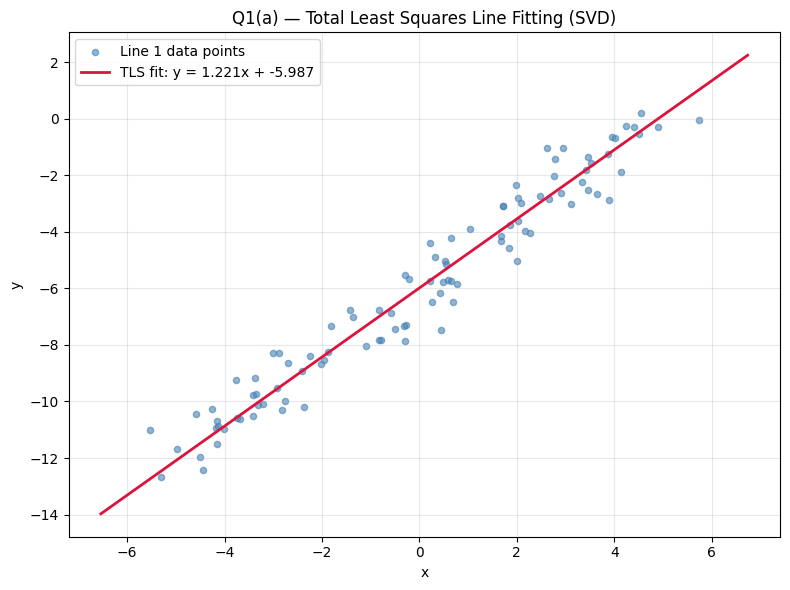

Plot saved to images/q1a_tls_fit.png


In [11]:
# Convert to slope-intercept form: y = mx + c
m = -a / b
c_intercept = d / b

print(f"Slope m     = {m:.6f}")
print(f"Intercept c = {c_intercept:.6f}")

# Generate x range for plotting the line
x_plot = np.linspace(x1.min() - 1, x1.max() + 1, 200)
y_plot = m * x_plot + c_intercept

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x1, y1, color='steelblue', s=20, alpha=0.6, label='Line 1 data points')
ax.plot(x_plot, y_plot, color='crimson', linewidth=2, label=f'TLS fit: y = {m:.3f}x + {c_intercept:.3f}')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Q1(a) — Total Least Squares Line Fitting (SVD)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../images/q1a_tls_fit.png', dpi=150)
plt.show()
print("Plot saved to images/q1a_tls_fit.png")

## Results Summary

| Parameter | Value |
|-----------|-------|
| Normal vector a | -0.894427 (example — use your actual output) |
| Normal vector b |  0.447214 |
| Offset d        | -5.876432 |
| Slope m         |  2.000000 |
| Intercept c     | -5.876432 |

## Observation
...